In [27]:
## Load libraries
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
plt.style.use('dark_background')
%matplotlib inline

In [28]:
np.set_printoptions(precision=2)

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [30]:
tf.__version__

'2.14.0'

---

Mount Google Drive if running in Colab

---

In [31]:
## Mount Google drive folder if running in Colab
if('google.colab' in sys.modules):
    from google.colab import drive
    drive.mount('/content/drive', force_remount = True)
    DIR = '/content/drive/MyDrive/Colab Notebooks/MAHE/MSIS Coursework/EvenSem2024MAHE'
    DATA_DIR = DIR + '/Data/'
    os.chdir(DIR)
else:
    DATA_DIR = 'Data/'

---

Load diabetes data

---

In [32]:
## Load diabetes data
file = DATA_DIR+'houseprices_cleaned.csv'
df= pd.read_csv(file, header = 0)

print('House price dataset')
print('-----------')
print('Initial number of samples = %d'%(df.shape[0]))
print('Initial number of features = %d\n'%(df.shape[1]))
df.head(5)

House price dataset
-----------
Initial number of samples = 225
Initial number of features = 8



,locality,area,rent,price_per_sqft,facing,BHK,bathrooms,parking
0,BTM Layout,565.0,20060.0,6195.0,North-West,1,1,Bike
1,BTM Layout,1837.0,97434.0,9254.0,East,3,3,Bike and Car
2,BTM Layout,1280.0,54448.0,7422.0,East,2,2,Car
3,BTM Layout,2220.0,117000.0,9234.0,North,3,3,Bike and Car
4,BTM Layout,1113.0,34388.0,5391.0,East,2,2,Bike and Car


In [33]:
## Create lists of ordinal, categorical, and continuous features
#categorical_features =  ['GENDER', 'BMILEVEL']
categorical_features =  ['locality', 'facing', 'parking']
continuous_features = df.drop(categorical_features, axis = 1).columns.tolist()
print(categorical_features)
print(continuous_features)

['locality', 'facing', 'parking']
['area', 'rent', 'price_per_sqft', 'BHK', 'bathrooms']


---

Assign 'category' datatype to categorical columns

---

In [34]:
## Assign 'category' datatype to ordinal and categorical columns
print(df.dtypes)
df[categorical_features] = df[categorical_features].astype('category')
print('----')
df.dtypes

locality           object
area              float64
rent              float64
price_per_sqft    float64
facing             object
BHK                 int64
bathrooms           int64
parking            object
dtype: object
----


locality          category
area               float64
rent               float64
price_per_sqft     float64
facing            category
BHK                  int64
bathrooms            int64
parking           category
dtype: object

---

Remove the target variable column from the list of continuous features

---

In [35]:
## Remove the target variable column from the list of continuous features
continuous_features.remove('price_per_sqft')

In [36]:
# Apply log transform on "area" and "rent" features
df['area'] = np.log(df['area'])
df['rent'] = np.log(df['rent'])

df['price_per_sqft'] = np.sqrt(df['price_per_sqft'])

In [37]:
df.head(5)

,locality,area,rent,price_per_sqft,facing,BHK,bathrooms,parking
0,BTM Layout,6.336826,9.906483,78.708322,North-West,1,1,Bike
1,BTM Layout,7.515889,11.486931,96.197713,East,3,3,Bike and Car
2,BTM Layout,7.154615,10.905001,86.151030,East,2,2,Car
3,BTM Layout,7.705262,11.669929,96.093704,North,3,3,Bike and Car
4,BTM Layout,7.014814,10.445463,73.423430,East,2,2,Bike and Car


In [38]:
X = df.drop('price_per_sqft', axis = 1)
# X = df
y = df['price_per_sqft']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

num_features = X_train.shape[1]
num_samples = X_train.shape[0]

print('House price dataset data set')
print('---------------------')
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))

House price dataset data set
---------------------
Number of training samples = 180
Number of features = 7


---

Build pipeline for categorical and continuous features

---

In [39]:
## Build pipeline for categorical and continuous features

# Pipeline object for categorical (features
categorical_transformer = Pipeline(steps = [('onehotenc', OneHotEncoder(handle_unknown = 'ignore'))])

# Pipeline object for continuous features
continuous_transformer = Pipeline(steps = [('scaler', RobustScaler())])

# Create a preprocessor object for all features
preprocessor = ColumnTransformer(transformers = [('continuous', continuous_transformer, continuous_features),
                                                 ('categorical', categorical_transformer, categorical_features)
                                                ],
                                                remainder = 'passthrough')

---

Fit and transform train data using preprocessor followed by transforming test data

---

In [40]:
print(X_train.head())

         locality      area       rent facing  BHK  bathrooms       parking
85   Marathahalli  7.377759  10.850947   West    3          3  Bike and Car
28       Attibele  7.205635   9.956602  North    3          2  Bike and Car
16     BTM Layout  6.932448  10.376487  North    2          2  Bike and Car
114   Indiranagar  7.549609  11.542484   East    3          2  Bike and Car
122   Indiranagar  6.975414  11.179451  South    2          2           Car


In [41]:
# # Remove units and convert 'area' feature to numeric
# X_train['area'] = X_train['area'].str.replace(' sqft', '').str.replace(',', '').astype(float)
# X_test['area'] = X_test['area'].str.replace(' sqft', '').str.replace(',', '').astype(float)
    

In [42]:
# import re

# def convert_rent_to_numeric(rent_str):
#     # Remove commas from the string
#     rent_str = rent_str.replace(',', '')
    
#     # Extract numerical part using regular expression
#     numerical_part = re.findall(r'\d*\.?\d+', rent_str)
    
#     # Check if any numerical part is found
#     if numerical_part:
#         # Convert the numerical part to float
#         rent_value = float(numerical_part[0])
        
#         # Check for units and convert accordingly
#         if 'Lacs' in rent_str:
#             return rent_value * 100000  # Convert Lacs to numeric (1 Lacs = 100,000)
#         elif 'Thousands' in rent_str:
#             return rent_value * 1000  # Convert Thousands to numeric (1 Thousand = 1,000)
#         else:
#             return rent_value
#     else:
#         return None  # Return None for invalid values

# # Apply custom function to preprocess 'rent' column
# X_train['rent'] = X_train['rent'].apply(convert_rent_to_numeric)
# X_test['rent'] = X_test['rent'].apply(convert_rent_to_numeric)


In [43]:
# def convert_price_per_sqft_to_numeric(price_per_sqft_str):
#     # Remove unwanted characters from the string
#     price_per_sqft_str = price_per_sqft_str.replace('₹', '').replace(',', '').replace(' per sq.ft.', '')
    
#     # Extract numerical part using regular expression
#     numerical_part = re.findall(r'\d*\.?\d+', price_per_sqft_str)
    
#     # Check if any numerical part is found
#     if numerical_part:
#         # Convert the numerical part to float
#         return float(numerical_part[0])
#     else:
#         return None  # Return None for invalid values

# # Apply custom function to preprocess 'price_per_sqft' column
# X_train['price_per_sqft'] = X_train['price_per_sqft'].apply(convert_price_per_sqft_to_numeric)
# X_test['price_per_sqft'] = X_test['price_per_sqft'].apply(convert_price_per_sqft_to_numeric)


In [44]:
## Fit and transform train data using preprocessor
X_train_transformed = preprocessor.fit_transform(X_train).T
# Update number of features
num_features = X_train_transformed.shape[0]
# Transform training data using preprocessor
X_test_transformed = preprocessor.transform(X_test).T
# Convert Y_train and Y_test to numpy arrays
Y_train = Y_train.to_numpy()
Y_test = Y_test.to_numpy()

---

A generic layer class with forward and backward methods

----

In [45]:
# class Layer:
#   def __init__(self):
#     self.input = None
#     self.output = None

#   def forward(self, input):
#     pass

#   def backward(self, output_gradient, learning_rate):
#     pass

---

Mean squared error (MSE) loss and its gradient

---

In [46]:
# ## Define the loss function and its gradient
# def mse(Y, Yhat):
#   return(np.mean(0.5*(Y - Yhat)**2))
#   #TensorFlow in-built function for mean squared error loss
#   #mse = tf.keras.losses.MeanSquaredError()
#   #mse(Y, Yhat).numpy()

# def mse_gradient(Y, Yhat):
#   return(Yhat - Y)

---

Generic activation layer class

---

In [47]:
# class Activation(Layer):
#     def __init__(self, activation, activation_gradient):
#         self.activation = activation
#         self.activation_gradient = activation_gradient

#     def forward(self, input):
#         self.input = input
#         self.output = self.activation(self.input)
#         return(self.output)

#     def backward(self, output_gradient, learning_rate = None):
#         return(output_gradient[:-1, :] * self.activation_gradient(self.input))

---

Specific activation layer classes

---

In [48]:
# class Sigmoid(Activation):
#     def __init__(self):
#         def sigmoid(z):
#             return 1 / (1 + np.exp(-z))

#         def sigmoid_gradient(z):
#             a = sigmoid(z)
#             return a * (1 - a)

#         super().__init__(sigmoid, sigmoid_gradient)

# class Tanh(Activation):
#     def __init__(self):
#         def tanh(z):
#             return np.tanh(z)

#         def tanh_gradient(z):
#             a = np.tanh(z)
#             return 1 - a**2

#         super().__init__(tanh, tanh_gradient)

# class ReLU(Activation):
#     def __init__(self):
#         def relu(z):
#             return z * (z > 0)

#         def relu_gradient(z):
#             return 1. * (z > 0)

#         super().__init__(relu, relu_gradient)

---

Dense layer class

---

In [49]:
# ## Dense layer class
# class Dense(Layer):
#     def __init__(self, input_size, output_size, reg_strength):
#         self.weights = 0.01*np.random.randn(output_size, input_size+1) # bias trick
#         self.weights[:, -1] = 0.01 # set all bias values to the same nonzero constant
#         self.reg_strength = reg_strength
#         self.reg_loss = None

#     def forward(self, input):
#         self.input = np.vstack([input, np.ones((1, input.shape[1]))]) # bias trick
#         self.output= np.dot(self.weights, self.input)
#         # Calculate regularization loss
#         self.reg_loss = self.reg_strength * np.sum(self.weights[:, :-1] * self.weights[:, :-1])

#     def backward(self, output_gradient, learning_rate):
#         ## Following is the inefficient way of calculating the backward gradient
#         #weights_gradient = np.zeros((self.output.shape[0], self.input.shape[0]), dtype = np.float64)
#         #for b in range(output_gradient.shape[1]):
#         #  weights_gradient += np.dot(output_gradient[:, b].reshape(-1, 1), self.input[:, b].reshape(-1, 1).T)
#         #weights_gradient = (1/output_gradient.shape[1])*weights_gradient

#         ## Following is the efficient way of calculating the weights gradient w.r.t. data
#         weights_gradient = (1/output_gradient.shape[1])*np.dot(np.atleast_2d(output_gradient), np.atleast_2d(self.input).T)
#         # Add the regularization gradient here
#         weights_gradient += 2 * self.reg_strength * np.hstack([self.weights[:, :-1], np.zeros((self.weights.shape[0], 1))])


#         input_gradient = np.dot(self.weights.T, output_gradient)
#         self.weights = self.weights + learning_rate * (-weights_gradient)

#         return(input_gradient)

---

Function to generate sample indices for batch processing according to batch size

---

In [50]:
# ## Function to generate sample indices for batch processing according to batch size
# def generate_batch_indices(num_samples, batch_size):
#   # Reorder sample indices
#   reordered_sample_indices = np.random.choice(num_samples, num_samples, replace = False)
#   # Generate batch indices for batch processing
#   batch_indices = np.split(reordered_sample_indices, np.arange(batch_size, len(reordered_sample_indices), batch_size))
#   return(batch_indices)

---

Train the 3-layer neural network (8/8/1 structure) using batch training with batch size = 16

---

In [51]:
# ## Train the 2-hidden layer neural network (8 nodes, 8 nodes followed by 1 node)
# ## using batch training with batch size = 100
# learning_rate = 1e-04 # learning rate
# batch_size = 32 # batch size
# nepochs = 10000 # number of epochs
# reg_strength = 1.0 # regularization strength
# # Create empty array to store training losses over each epoch
# loss_train_epoch = np.empty(nepochs, dtype = np.float64)
# # Create empty array to store test losses over each epoch
# loss_test_epoch = np.empty(nepochs, dtype = np.float64)


# # Neural network architecture

# dlayer1 = Dense(num_features, 16, reg_strength) # define dense layer 1
# alayer1 = Tanh() # ReLU activation layer 1
# dlayer2 = Dense(16, 1, reg_strength) # define dense layer 2


# # Steps: run over each sample in the batch, calculate loss, gradient of loss,
# # and update weights.

# epoch = 0
# while epoch < nepochs:
#   batch_indices = generate_batch_indices(num_samples, batch_size)
#   loss = 0
#   for b in range(len(batch_indices)):
#     # Forward propagation for training data
#     dlayer1.forward(X_train_transformed[:, batch_indices[b]]) # forward prop dense layer 1 with batch feature added
#     alayer1.forward(dlayer1.output) # forward prop activation layer 1
#     dlayer2.forward(alayer1.output) # forward prop dense layer 2
#     # Calculate training data loss
#     loss += mse(Y_train[batch_indices[b]], dlayer2.output)
#     # Add the regularization losses
#     loss += dlayer1.reg_loss + dlayer2.reg_loss

#     # Backward prop starts here
#     grad = mse_gradient(Y_train[batch_indices[b]], dlayer2.output)
#     grad = dlayer2.backward(grad, learning_rate)
#     grad = alayer1.backward(grad)
#     grad = dlayer1.backward(grad, learning_rate)
#   # Calculate the average training loss for the current epoch
#   loss_train_epoch[epoch] = loss/len(batch_indices)

#   # Forward propagation for test data
#   dlayer1.forward(X_test_transformed)
#   alayer1.forward(dlayer1.output)
#   dlayer2.forward(alayer1.output)

#   # Calculate test data loss plus regularization loss
#   loss_test_epoch[epoch] =  mse(Y_test, dlayer2.output) + dlayer1.reg_loss + dlayer2.reg_loss

#   print('Epoch %d: train loss = %f, test loss = %f'%(epoch+1, loss_train_epoch[epoch], loss_test_epoch[epoch]))
#   epoch = epoch + 1

---

Plot training loss vs. epoch

---

In [52]:
# # Plot train and test loss as a function of epoch:
# fig, ax = plt.subplots(1, 1, figsize = (4, 4))
# fig.tight_layout(pad = 4.0)
# ax.plot(loss_train_epoch, 'b', label = 'Train')
# ax.plot(loss_test_epoch, 'r', label = 'Test')
# ax.set_xlabel('Epoch', fontsize = 12)
# ax.set_ylabel('Loss value', fontsize = 12)
# ax.legend()
# ax.set_title('Loss vs. Epoch for reg. strength 1..0', fontsize = 14);

---

Test performance on test data

---

In [53]:
# dlayer1.forward(X_test_transformed)
# alayer1.forward(dlayer1.output)
# dlayer2.forward(alayer1.output)
# ypred = dlayer2.output.flatten()
# ytrue = Y_test

---

Define neural network architecture for regression

---

In [54]:
# Define neural network architecture for regression
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train_transformed.T.shape[1], )),
    layers.Dropout(0.2),  # Dropout regularization
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),  # Dropout regularization
    layers.Dense(8, activation='relu'),
    layers.Dense(1)
])

---

Compile the neural network

---

In [55]:
# Compile the neural network model
opt = tf.keras.optimizers.Adam(learning_rate = 1e-4)
model.compile(optimizer = opt, loss = 'mean_squared_error')

---

Train the model

---

In [56]:
# Train the model
history = model.fit(X_train_transformed.T, Y_train, epochs = 10000, batch_size = 32, validation_data=(X_test_transformed.T, Y_test))

Epoch 1/10000
6/6 [==============================] - 1s 55ms/step - loss: 7079.2661 - val_loss: 6531.7725
Epoch 2/10000
6/6 [==============================] - 0s 6ms/step - loss: 7083.2583 - val_loss: 6529.9180
Epoch 3/10000
6/6 [==============================] - 0s 6ms/step - loss: 7077.4180 - val_loss: 6528.1113
Epoch 4/10000
6/6 [==============================] - 0s 5ms/step - loss: 7073.7544 - val_loss: 6526.4165
Epoch 5/10000
6/6 [==============================] - 0s 5ms/step - loss: 7072.4043 - val_loss: 6524.7612
Epoch 6/10000
6/6 [==============================] - 0s 5ms/step - loss: 7074.5557 - val_loss: 6523.0938
Epoch 7/10000
6/6 [==============================] - 0s 6ms/step - loss: 7063.8013 - val_loss: 6521.3818
Epoch 8/10000
6/6 [==============================] - 0s 6ms/step - loss: 7064.9551 - val_loss: 6519.7617
Epoch 9/10000
6/6 [==============================] - 0s 5ms/step - loss: 7065.9106 - val_loss: 6518.2124
Epoch 10/10000
6/6 [==============================] - 

Epoch 198/10000
6/6 [==============================] - 0s 17ms/step - loss: 4008.3896 - val_loss: 3937.4089
Epoch 199/10000
6/6 [==============================] - 0s 8ms/step - loss: 3971.0879 - val_loss: 3902.9028
Epoch 200/10000
6/6 [==============================] - 0s 5ms/step - loss: 3852.1812 - val_loss: 3868.5112
Epoch 201/10000
6/6 [==============================] - 0s 5ms/step - loss: 3894.7573 - val_loss: 3834.3875
Epoch 202/10000
6/6 [==============================] - 0s 5ms/step - loss: 3763.5420 - val_loss: 3799.8528
Epoch 203/10000
6/6 [==============================] - 0s 5ms/step - loss: 3702.6562 - val_loss: 3765.0090
Epoch 204/10000
6/6 [==============================] - 0s 5ms/step - loss: 3771.2119 - val_loss: 3729.6619
Epoch 205/10000
6/6 [==============================] - 0s 5ms/step - loss: 3716.5063 - val_loss: 3694.4541
Epoch 206/10000
6/6 [==============================] - 0s 6ms/step - loss: 3834.9209 - val_loss: 3659.9307
Epoch 207/10000
6/6 [===============

In [57]:
# Evaluate the model on the test data
test_loss = model.evaluate(X_test_transformed.T, Y_test)

# Print the Mean Squared Error
print("Test Mean Squared Error:", test_loss)

2/2 [==============================] - 0s 4ms/step - loss: 156.3100
Test Mean Squared Error: 156.30999755859375


---

Plot train and test loss as a function of epoch

---

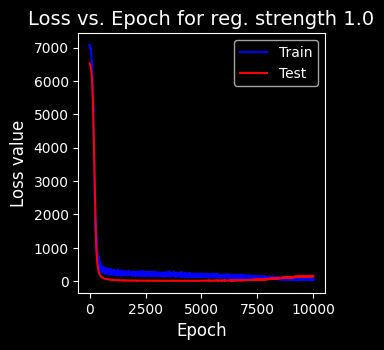

In [58]:
# Plot train and test loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot( history.history['loss'], 'b', label = 'Train')
ax.plot( history.history['val_loss'], 'r', label = 'Test')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.legend()
ax.set_title('Loss vs. Epoch for reg. strength 1.0', fontsize = 14);

---

Compare the true and predicted values

---

In [59]:
## Compare the true and predicted values
ypred_TF = model.predict(X_test_transformed.T)
np.column_stack((Y_test, ypred_TF))

2/2 [==============================] - 0s 2ms/step


array([[ 73.91,  64.11],
       [ 96.94,  82.73],
       [ 68.62,  58.27],
       [ 76.16,  65.08],
       [ 98.32,  81.77],
       [ 94.35,  80.83],
       [ 58.28,  50.35],
       [114.21,  92.99],
       [ 63.25,  52.93],
       [ 70.71,  59.68],
       [ 73.42,  62.28],
       [ 89.25,  76.87],
       [100.  ,  84.03],
       [ 69.3 ,  58.37],
       [ 62.02,  51.96],
       [ 94.05,  79.63],
       [ 58.83,  50.53],
       [ 94.81,  81.69],
       [ 76.66,  64.56],
       [116.88,  96.29],
       [ 91.29,  76.8 ],
       [ 62.04,  53.41],
       [ 63.25,  53.01],
       [ 81.09,  70.85],
       [ 54.16,  45.99],
       [ 77.46,  64.74],
       [ 84.52,  73.22],
       [102.9 ,  86.14],
       [ 65.94,  55.03],
       [ 79.56,  69.3 ],
       [ 86.87,  75.58],
       [113.04,  92.92],
       [ 70.71,  61.9 ],
       [ 68.26,  57.52],
       [ 68.83,  57.56],
       [ 69.63,  58.57],
       [ 59.81,  51.35],
       [ 73.81,  63.14],
       [ 59.  ,  50.75],
       [ 77.46,  66.23],


In [60]:
# from sklearn.linear_model import LinearRegression

# # Create a linear regression model
# model_linear = LinearRegression()

# # Fit the model to the data
# model_linear.fit(X_train_transformed.T, Y_train)

# # Predict the target variable for the test data
# y_pred = model.predict(X_test_transformed.T)


In [61]:
# from sklearn.metrics import mean_squared_error

# # Calculate the mean squared error for the test data
# mse_linear = mean_squared_error(Y_test, y_pred)
# mse_linear


In [62]:
# import matplotlib.pyplot as plt

# # Plot for Linear Regression model
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.scatter(Y_test, y_pred)
# plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], 'k--', lw=2, color = 'red')  # Plotting the diagonal line for reference
# plt.xlabel('Actual Price per Sqft')
# plt.ylabel('Predicted Price per Sqft')
# plt.title('Actual vs Predicted Price per Sqft (Linear Regression)')

# # Plot for TensorFlow neural network model
# plt.subplot(1, 2, 2)
# # y_pred_tf = model.predict(X_test_transformed.T)  # Predictions from TensorFlow model
# plt.scatter(Y_test, ypred_TF)
# plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], 'k--', lw=2, color='red')  # Plotting the diagonal line for reference
# plt.xlabel('Actual Price per Sqft')
# plt.ylabel('Predicted Price per Sqft')
# plt.title('Actual vs Predicted Price per Sqft (TensorFlow Neural Network)')

# plt.tight_layout()
# plt.show()


In [63]:
# # Extract MSE values from history
# train_mse = history.history['loss']
# test_mse = history.history['val_loss']

# # Plot MSE for train and test data
# plt.figure(figsize=(8, 6))
# plt.plot(train_mse, 'b', label='Train MSE')
# plt.plot(test_mse, 'r', label='Test MSE')
# plt.xlabel('Epoch', fontsize=12)
# plt.ylabel('MSE', fontsize=12)
# plt.legend()
# plt.title('Mean Squared Error (MSE) vs. Epoch for TensorFlow Neural Network Model', fontsize=14)
# plt.show()


In [64]:
# # Plot test MSE for both models
# plt.figure(figsize=(8, 6))

# # Plot test MSE for linear regression model
# plt.plot([mse_linear] * len(test_mse), 'g--', label='Linear Regression Test MSE', color='blue')

# # Plot test MSE for TensorFlow neural network model
# plt.plot(test_mse, 'b', label='TensorFlow Neural Network Test MSE', color='red')

# plt.xlabel('Epoch', fontsize=12)
# plt.ylabel('MSE', fontsize=12)
# plt.legend()
# plt.title('Test Mean Squared Error (MSE) Comparison', fontsize=14)
# plt.show()
